# PyTorch VAE with DBSCAN Clustering and Evaluation

This notebook applies a Variational Autoencoder using PyTorch to create a two-dimensional latent representation of the patient data.

DBSCAN is then applied to the learned VAE representation to identify patient subpopulations.

The final VAE and DBSCAN parameters were selected during the separate hyperparameter tuning process and are written directly in this notebook.

The workflow includes:

1. Load the prepared scaled clustering dataset.
2. Train a PyTorch Variational Autoencoder.
3. Create a two-dimensional latent representation.
4. Apply DBSCAN clustering.
5. Evaluate clustering quality.
6. Compare the clustering result with Ju and Dubin.
7. Compare clinical outcomes across clusters.
8. Evaluate ICU survival across clusters.
9. Examine clinical features that distinguish the clusters.
10. Save the essential results and plots.

## Setup and Data

### Import Required Libraries

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# DBSCAN clustering
from sklearn.cluster import DBSCAN

# Internal clustering evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

#### Observation :
- Imports all libraries needed for data handling, visualization, VAE modeling, DBSCAN clustering, cluster evaluation, and survival analysis.
- PyTorch components are imported to build and train the Variational Autoencoder (VAE) and manage patient data in batches.
- The three clustering metrics—Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score—are included to evaluate how well the identified patient clusters are separated.
- Kaplan-Meier analysis and the multivariate log-rank test are imported to compare survival outcomes across multiple patient clusters.
- Overall, this block prepares the complete analytical environment for identifying and clinically evaluating sepsis patient subgroups using VAE and DBSCAN.

### Set Plot Style

In [2]:
# Apply a clean style to all plots
sns.set_theme(style="whitegrid")

#### Observation :
- Sets Seaborn’s `whitegrid` theme as the default style for all visualizations.
- The grid background makes cluster patterns, distributions, and clinical comparisons easier to read.
- This ensures a consistent and clear visual style across all plots generated in the VAE-DBSCAN analysis.

### Set Random Seed and PyTorch Device

In [3]:
# Fixed random seed improves reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Also set the seed for GPU operations when available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# Use GPU when available, otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Random state:", RANDOM_STATE)
print("PyTorch device:", device)

Random state: 42
PyTorch device: cuda


#### Observation :
- Sets a fixed random seed of $42$ across Python, NumPy, and PyTorch to make the VAE results reproducible across runs.
- Configures PyTorch to use GPU acceleration when CUDA is available; otherwise, it automatically uses the CPU.
- This block ensures consistent model training and efficient computation for the VAE analysis.

### Set Project Folder Paths

In [4]:
# Move two levels upward to reach the project root
ROOT = Path.cwd().parents[1]

# Original eICU tables
DATA_DIR = ROOT / "data"

# Prepared clustering dataset
DATASET_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "dataset_creation"
)

# Results produced by this notebook
RESULTS_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "vae_dbscan"
)

# Plots produced by this notebook
PLOTS_DIR = (
    ROOT
    / "plots"
    / "module_2"
    / "vae_dbscan"
)

# Create output folders if they do not already exist
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", ROOT)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)
print("Plots folder:", PLOTS_DIR)

Project root: C:\Users\samsa\Documents\ICU Clustering
Dataset folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\vae_dbscan
Plots folder: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\vae_dbscan


#### Observation :
- Defines the main project paths for the original eICU data, prepared clustering dataset, analysis results, and generated plots.
- Keeps the VAE-DBSCAN workflow organized by separating input data, numerical results, and visual outputs into dedicated folders.
- Automatically creates the required results and plot directories if they do not already exist.
- This ensures all files used and generated during the analysis are stored in a consistent and reproducible project structure.

### Load the Scaled Clustering Dataset

In [5]:
# Final Min-Max scaled clustering dataset
SCALED_DATA_PATH = (
    DATASET_DIR / "feature_data_scaled.csv"
)

# File containing the clustering feature names
FEATURE_NAMES_PATH = (
    DATASET_DIR / "clustering_feature_names.csv"
)

# Load the scaled patient dataset
scaled_df = pd.read_csv(
    SCALED_DATA_PATH
)

# Load the clustering feature names
feature_names_df = pd.read_csv(
    FEATURE_NAMES_PATH
)

print(
    "Scaled dataset shape:",
    scaled_df.shape
)

scaled_df.head()

Scaled dataset shape: (7648, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,1.0,0.271546,0.077035,0.055777,0.270588,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,210208,0.472222,0.0,0.267434,0.058982,0.039841,0.476471,0.016535,0.321429,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,1.0,0.254770,0.061000,0.183267,0.400000,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,1.0,0.275658,0.075577,0.039841,0.700000,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,166175,0.583333,0.0,0.304934,0.100695,0.023904,0.535294,0.043701,0.428571,0.414634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Observation :
- Loads the Min-Max scaled patient dataset that will be used as input for the VAE and DBSCAN clustering.
- Loads the saved clustering feature names to ensure the analysis uses the same variables selected during dataset preparation.
- The scaled dataset contains $7,648$ ICU stays and $81$ columns.
- This block confirms that the prepared patient data and feature information are successfully loaded for the VAE-based clustering analysis.

### Load the Clustering Feature Names

In [6]:
# The first column contains the saved clustering feature names
feature_cols = (
    feature_names_df.iloc[:, 0]
    .astype(str)
    .tolist()
)

print(
    "Number of saved clustering features:",
    len(feature_cols)
)

feature_cols[:10]

Number of saved clustering features: 80


['age',
 'gender',
 'admissionheight',
 'admissionweight',
 'min_BUN',
 'min_Hgb',
 'min_WBC x 1000',
 'min_anion gap',
 'min_bicarbonate',
 'min_chloride']

#### Observation :
- Extracts the saved clustering feature names from the feature-name file and converts them into a Python list.
- Confirms that $80$ clinical features were selected for the clustering analysis.
- Displays the first few feature names to verify that variables such as age, gender, admission measurements, and laboratory values are included.
- This ensures the VAE uses the same predefined clinical feature set prepared during dataset creation.

### Prepare the Clustering Matrix

In [7]:
# Unique eICU ICU-stay identifier
ID_COL = "patientunitstayid"

# Keep only feature names that exist in the scaled dataset
feature_cols = [
    feature
    for feature in feature_cols
    if feature in scaled_df.columns
]

# X contains only variables used for clustering
X = scaled_df[
    feature_cols
].copy()

print(
    "Patients:",
    len(X)
)

print(
    "Clustering features:",
    X.shape[1]
)

Patients: 7648
Clustering features: 80


#### Observation :
- Defines `patientunitstayid` as the unique identifier for each ICU stay.
- Checks the selected feature list against the scaled dataset and keeps only features that are actually available.
- Creates the clustering matrix `X` using only the clinical variables intended for VAE modeling and DBSCAN clustering.
- The final matrix contains $7,648$ ICU stays and $80$ clustering features, confirming that all selected features are available for analysis.

### Verify the Clustering Matrix

In [8]:
# Check for duplicate ICU stays
print(
    "Duplicate patient IDs:",
    scaled_df[ID_COL].duplicated().sum()
)

# VAE requires complete numerical data
print(
    "Missing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        X.to_numpy()
    ).sum()
)

# Data were previously Min-Max scaled
print(
    "Minimum feature value:",
    X.min().min()
)

print(
    "Maximum feature value:",
    X.max().max()
)

Duplicate patient IDs: 0
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


#### Observation :
- Confirms there are no duplicate ICU stay IDs, so each patient stay is represented only once.
- Verifies that the clustering matrix contains no missing or infinite values, making it suitable for VAE training.
- Confirms the feature values are Min-Max scaled between approximately $0$ and $1$.
- Overall, this block verifies that the patient feature matrix is clean, complete, and ready for VAE modeling.

## PyTorch Variational Autoencoder

### Set the Final VAE Parameters

In [9]:
# Final VAE parameters selected during hyperparameter tuning

VAE_HIDDEN_1 = 256
VAE_HIDDEN_2 = 128

# Two dimensions are required for the final latent representation
VAE_LATENT_DIM = 2

VAE_LEARNING_RATE = 0.0001
VAE_BETA = 0.1

VAE_BATCH_SIZE = 128
VAE_EPOCHS = 50

print("Hidden layer 1:", VAE_HIDDEN_1)
print("Hidden layer 2:", VAE_HIDDEN_2)
print("Latent dimensions:", VAE_LATENT_DIM)
print("Learning rate:", VAE_LEARNING_RATE)
print("Beta:", VAE_BETA)
print("Batch size:", VAE_BATCH_SIZE)
print("Epochs:", VAE_EPOCHS)

Hidden layer 1: 256
Hidden layer 2: 128
Latent dimensions: 2
Learning rate: 0.0001
Beta: 0.1
Batch size: 128
Epochs: 50


#### Observation :
- Defines the final VAE architecture and training parameters selected during hyperparameter tuning.
- Uses two hidden layers with $256$ and $128$ neurons to learn compressed patterns from the clinical features.
- Sets the latent space to $2$ dimensions, allowing each ICU stay to be represented by two learned VAE features for clustering and visualization.
- Uses a learning rate of $0.0001$, beta of $0.1$, batch size of $128$, and $50$ training epochs for the final VAE model.
- Overall, this block fixes the optimized VAE configuration that will be used to generate the latent representation for DBSCAN clustering.

### Convert the Data to a Pytorch Tensor

In [10]:
# Convert the Pandas DataFrame into a PyTorch tensor
X_tensor = torch.tensor(
    X.to_numpy(dtype=np.float32),
    dtype=torch.float32
)

print(
    "PyTorch tensor shape:",
    X_tensor.shape
)

PyTorch tensor shape: torch.Size([7648, 80])


#### Observation :
- Converts the prepared Pandas clustering matrix into a PyTorch tensor so it can be used by the VAE.
- Uses $32$-bit floating-point values (`float32`), which is the standard numerical format for neural network training in PyTorch.
- Preserves the full patient-feature structure, producing a tensor with $7,648$ ICU stays and $80$ clinical features.
- This block makes the processed clinical data ready for batch-based VAE training.

### Create the PyTorch DataLoader

The DataLoader divides the patient data into smaller batches.

Instead of passing every patient through the neural network at the same time, the model learns from smaller groups of patients during each training epoch.

In [11]:
# Create a PyTorch dataset
vae_dataset = TensorDataset(
    X_tensor
)

# Divide the data into smaller training batches
vae_loader = DataLoader(
    vae_dataset,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True
)

print(
    "Number of training batches:",
    len(vae_loader)
)

Number of training batches: 60


#### Observation :
- Wraps the patient tensor in a PyTorch `TensorDataset` so it can be efficiently used during VAE training.
- Divides the $7,648$ ICU stays into smaller batches of $128$ patients instead of processing the entire dataset at once.
- Enables data shuffling so patients are presented in a different order during training, reducing dependence on the original data order.
- Creates $60$ training batches, providing an efficient batch-based input pipeline for training the VAE.

### Define the PyTorch VAE


#### Variational Autoencoder Structure

The VAE contains two major parts:

##### Encoder

The encoder reduces the original high-dimensional patient features into a smaller latent representation.

The architecture is:
$$
\text{Input Features} → 64 → 32 → \text{2-D Latent Space}
$$

##### Decoder

The decoder attempts to reconstruct the original patient features from the two-dimensional latent representation.

The architecture is:
$$
\text{2-D Latent Space} → 32 → 64 → \text{Original Features}
$$
The VAE learns two values for each latent dimension:

- Mean
- Log variance

These values describe the latent probability distribution for each patient.

In [12]:
class VAE(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        # -----------------------
        # Encoder
        # -----------------------

        self.encoder_1 = nn.Linear(
            input_dim,
            VAE_HIDDEN_1
        )

        self.encoder_2 = nn.Linear(
            VAE_HIDDEN_1,
            VAE_HIDDEN_2
        )

        # Latent mean
        self.mean_layer = nn.Linear(
            VAE_HIDDEN_2,
            VAE_LATENT_DIM
        )

        # Latent log variance
        self.log_var_layer = nn.Linear(
            VAE_HIDDEN_2,
            VAE_LATENT_DIM
        )

        # -----------------------
        # Decoder
        # -----------------------

        self.decoder_1 = nn.Linear(
            VAE_LATENT_DIM,
            VAE_HIDDEN_2
        )

        self.decoder_2 = nn.Linear(
            VAE_HIDDEN_2,
            VAE_HIDDEN_1
        )

        self.output_layer = nn.Linear(
            VAE_HIDDEN_1,
            input_dim
        )

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()


    def encode(self, x):

        # Reduce the original features
        x = self.relu(
            self.encoder_1(x)
        )

        x = self.relu(
            self.encoder_2(x)
        )

        # Create latent distribution
        mean = self.mean_layer(x)

        log_var = self.log_var_layer(x)

        return mean, log_var


    def reparameterize(
        self,
        mean,
        log_var
    ):

        # Convert log variance into standard deviation
        std = torch.exp(
            0.5 * log_var
        )

        # Create random normal noise
        epsilon = torch.randn_like(
            std
        )

        # Sample from the latent distribution
        z = mean + epsilon * std

        return z


    def decode(self, z):

        # Expand the latent representation
        x = self.relu(
            self.decoder_1(z)
        )

        x = self.relu(
            self.decoder_2(x)
        )

        # Sigmoid keeps reconstructed values
        # approximately between 0 and 1
        reconstruction = self.sigmoid(
            self.output_layer(x)
        )

        return reconstruction


    def forward(self, x):

        # Encode patient data
        mean, log_var = self.encode(x)

        # Create latent representation
        z = self.reparameterize(
            mean,
            log_var
        )

        # Reconstruct the original features
        reconstruction = self.decode(z)

        return (
            reconstruction,
            mean,
            log_var
        )

#### Observation :
- Defines the complete Variational Autoencoder (VAE) architecture used to compress the $80$ clinical features into a lower-dimensional representation.
- The encoder reduces the patient data through hidden layers of $256$ and $128$ neurons and learns a $2$-dimensional latent mean and log variance.
- The reparameterization step introduces controlled random sampling so the model can learn a continuous latent representation while remaining trainable.
- The decoder reconstructs the original clinical features from the $2$-dimensional latent space using the reverse network structure.
- ReLU activation is used in the hidden layers, while Sigmoid activation is used at the output because the input clinical features are Min-Max scaled.
- Overall, this block builds the VAE that will learn a compact $2$-dimensional representation of sepsis patients for DBSCAN clustering.

### Create the VAE Model

In [13]:
# Number of original clustering features
INPUT_DIM = X.shape[1]

# Create the VAE
vae_model = VAE(
    input_dim=INPUT_DIM
)

# Move the model to CPU or GPU
vae_model = vae_model.to(
    device
)

print(vae_model)

VAE(
  (encoder_1): Linear(in_features=80, out_features=256, bias=True)
  (encoder_2): Linear(in_features=256, out_features=128, bias=True)
  (mean_layer): Linear(in_features=128, out_features=2, bias=True)
  (log_var_layer): Linear(in_features=128, out_features=2, bias=True)
  (decoder_1): Linear(in_features=2, out_features=128, bias=True)
  (decoder_2): Linear(in_features=128, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=80, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


#### Observation :
- Sets the VAE input dimension to the number of clinical clustering features in the dataset.
- Creates the VAE model using the architecture defined in the previous block.
- Moves the model to the selected CPU or GPU device for training.
- Confirms that the VAE is ready to learn a $2$-dimensional latent representation of the sepsis patient data.

### Define the VAE Optimizer

In [14]:
# Adam updates the neural-network weights during training
optimizer = torch.optim.Adam(
    vae_model.parameters(),
    lr=VAE_LEARNING_RATE
)

print(
    "Optimizer: Adam"
)

print(
    "Learning rate:",
    VAE_LEARNING_RATE
)

Optimizer: Adam
Learning rate: 0.0001


#### Observation :
- Uses the Adam optimizer to update the VAE model weights during training.
- Sets the learning rate to $0.0001$, based on the final hyperparameter configuration.
- Adam provides adaptive weight updates, helping the VAE learn the underlying patterns in the clinical data efficiently.
- This block prepares the optimization process required to train the VAE model on the sepsis patient features.

### Understand the VAE Loss

The VAE uses two types of loss.

#### Reconstruction Loss

Reconstruction loss measures how closely the decoder can reproduce the original patient features.

A smaller reconstruction loss means that the VAE preserves more information from the original data.

#### KL Divergence

KL divergence organizes the latent representation into a smoother probability distribution.

The beta value controls how strongly KL divergence affects the total VAE loss.

The total loss is:

Total Loss = Reconstruction Loss + Beta × KL Divergence

### Train the VAE

In [15]:
# Store the average loss from every epoch
training_losses = []

# Put the VAE into training mode
vae_model.train()

for epoch in range(VAE_EPOCHS):

    epoch_loss = 0

    for batch in vae_loader:

        # Get the patient feature batch
        batch_x = batch[0].to(
            device
        )

        # Clear gradients from the previous step
        optimizer.zero_grad()

        # Pass the data through the VAE
        reconstruction, mean, log_var = (
            vae_model(batch_x)
        )

        # -----------------------
        # Reconstruction loss
        # -----------------------

        reconstruction_loss = (
            nn.functional.mse_loss(
                reconstruction,
                batch_x,
                reduction="sum"
            )
        )

        # -----------------------
        # KL divergence
        # -----------------------

        kl_loss = -0.5 * torch.sum(
            1
            + log_var
            - mean.pow(2)
            - log_var.exp()
        )

        # -----------------------
        # Total VAE loss
        # -----------------------

        loss = (
            reconstruction_loss
            + VAE_BETA * kl_loss
        )

        # Calculate gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

        epoch_loss += loss.item()

    # Average loss per patient
    average_loss = (
        epoch_loss / len(X_tensor)
    )

    training_losses.append(
        average_loss
    )

    # Print progress every 10 epochs
    if (
        (epoch + 1) % 10 == 0
        or epoch == 0
    ):

        print(
            f"Epoch {epoch + 1:02d}/{VAE_EPOCHS} "
            f"- Loss: {average_loss:.4f}"
        )

Epoch 01/50 - Loss: 8.8997
Epoch 10/50 - Loss: 1.5943
Epoch 20/50 - Loss: 1.4883
Epoch 30/50 - Loss: 1.2238
Epoch 40/50 - Loss: 1.1178
Epoch 50/50 - Loss: 1.0605


#### Observation :
- Trains the VAE for 50 epochs using the prepared batches of sepsis patient data.
- Calculates the total training loss using reconstruction loss plus beta-weighted KL divergence.
- Uses backpropagation and the Adam optimizer to update the VAE parameters after each batch.
- The average training loss decreases from $8.8997$ at epoch $1$ to $1.0605$ at epoch $50$, showing that the model progressively learns to reconstruct the clinical data more accurately.
- Overall, the steady reduction in loss indicates that the VAE training converged successfully and learned a meaningful compressed representation of the patient features.

### Check the Final Training Loss

In [16]:
print(
    "Initial training loss:",
    round(training_losses[0], 4)
)

print(
    "Final training loss:",
    round(training_losses[-1], 4)
)

Initial training loss: 8.8997
Final training loss: 1.0605


Observation :
- Compares the initial and final VAE training losses to assess how much the model improved during training.
- The loss decreases from $8.8997$ to $1.0605$, showing a substantial improvement in reconstructing the patient clinical features.
- The large reduction in loss indicates that the VAE successfully learned the underlying structure of the sepsis patient data.
- This confirms that the trained VAE is suitable for generating the latent representation used in the next clustering steps.

## Create the Two-Dimensional VAE Representation

### Extract the Latent Mean

For clustering, the latent mean is used instead of a randomly sampled latent value.

The sampled latent value contains random noise because of the VAE reparameterization process.

Using the latent mean gives each patient a stable two-dimensional representation for DBSCAN clustering.

In [17]:
# Put the VAE into evaluation mode
vae_model.eval()

# Turn off gradient calculation
with torch.no_grad():

    # Move the complete dataset to the PyTorch device
    X_device = X_tensor.to(
        device
    )

    # Get the two-dimensional latent mean
    latent_mean, latent_log_var = (
        vae_model.encode(
            X_device
        )
    )

# Move the latent representation back to CPU
vae_embedding = (
    latent_mean
    .cpu()
    .numpy()
)

print(
    "Original feature matrix:",
    X.shape
)

print(
    "VAE latent representation:",
    vae_embedding.shape
)

Original feature matrix: (7648, 80)
VAE latent representation: (7648, 2)


#### Observation :
- Switches the trained VAE to evaluation mode and disables gradient calculation because the model is no longer being trained.
- Passes all $7,648$ ICU stays through the encoder to obtain the learned latent mean for each patient.
- Uses the latent mean instead of random latent samples, giving a stable and reproducible representation for clustering.
- Reduces the original $80$ clinical features to $2$ VAE latent features, producing a final representation of $7,648 × 2$.
- This two-dimensional representation is the compressed patient feature space that will be used for DBSCAN clustering.

### Create the VAE Results Table

In [18]:
# Store patient IDs and the two latent coordinates
vae_results = pd.DataFrame({
    ID_COL: scaled_df[ID_COL].values,
    "vae_1": vae_embedding[:, 0],
    "vae_2": vae_embedding[:, 1]
})

vae_results.head()

,patientunitstayid,vae_1,vae_2
0,151900,-1.065383,-1.779347
1,210208,-1.118235,-0.459498
2,179269,1.497649,-0.330566
3,172764,1.485935,-0.339782
4,166175,-0.105736,1.635214


#### Observation :
- Creates a new results table containing each patient’s unique ICU stay ID and the two learned VAE latent coordinates.
- Stores the compressed dimensions as `vae_1` and `vae_2`, representing each patient in the two-dimensional latent space.
- Keeps the patient identifier linked to the latent features so clustering results can later be matched back to the original clinical records.
- This table becomes the main dataset used for VAE visualization and DBSCAN clustering.

### Plot the VAE Latent Representation

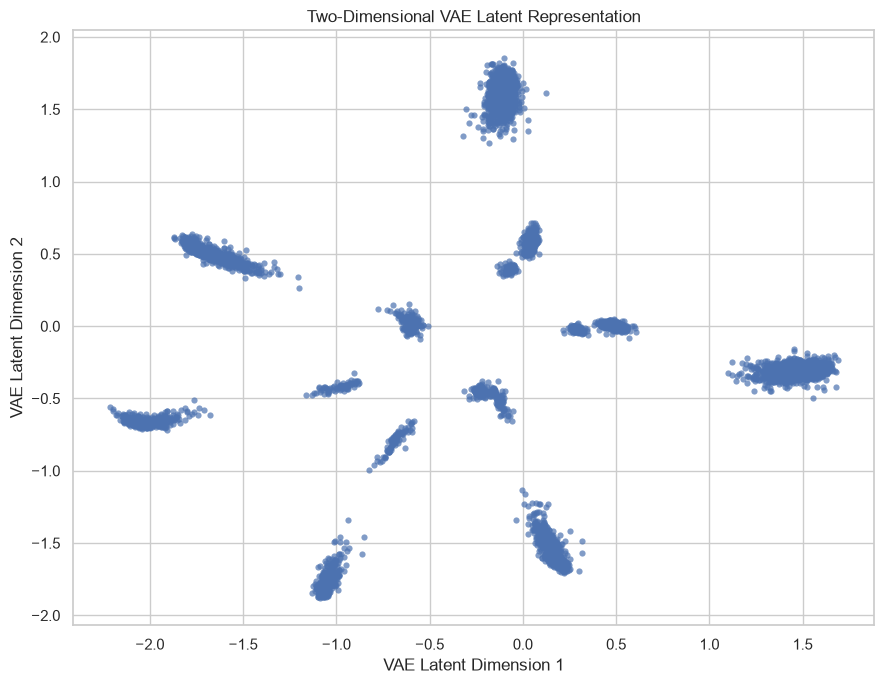

In [19]:
plt.figure(
    figsize=(9, 7)
)

# Plot all patients before DBSCAN clustering
sns.scatterplot(
    data=vae_results,
    x="vae_1",
    y="vae_2",
    s=20,
    alpha=0.7,
    linewidth=0
)

plt.title(
    "Two-Dimensional VAE Latent Representation"
)

plt.xlabel(
    "VAE Latent Dimension 1"
)

plt.ylabel(
    "VAE Latent Dimension 2"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "vae_latent_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a scatter plot of all $7,648$ ICU stays using the two learned VAE latent dimensions.
- Each point represents one patient’s position in the compressed two-dimensional clinical feature space.
- The plot helps visually assess whether the VAE has formed distinct patient groupings, dense regions, or overlapping patterns before clustering.
- The visualization is saved as `vae_latent_representation.png` for later analysis and reporting.
- This block provides the first visual view of the patient structure learned by the VAE before applying DBSCAN.

## DBSCAN Clustering

### Set the Final DBSCAN Parameters

In [20]:
# Final DBSCAN parameters selected during tuning
DBSCAN_EPS = 0.20
DBSCAN_MIN_SAMPLES = 50

print(
    "DBSCAN epsilon:",
    DBSCAN_EPS
)

print(
    "DBSCAN min_samples:",
    DBSCAN_MIN_SAMPLES
)

DBSCAN epsilon: 0.2
DBSCAN min_samples: 50


#### Observation :
- Sets the final DBSCAN hyperparameters selected during the tuning process.
- Uses an epsilon (`eps`) of $0.20$, which defines the maximum distance for two patients to be considered neighbors in the VAE latent space.
- Sets `min_samples` to $50$, requiring at least $50$ nearby patients to form a dense cluster region.
- These parameters determine how DBSCAN will identify distinct sepsis patient subgroups and potential outliers from the VAE representation.

### Apply DBSCAN to the VAE Representation

In [21]:
# Create the DBSCAN model
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric="euclidean"
)

# Assign every patient to a cluster
cluster_labels = dbscan.fit_predict(
    vae_embedding
)

# Add cluster labels to the VAE results
vae_results["cluster"] = (
    cluster_labels
)

vae_results.head()

,patientunitstayid,vae_1,vae_2,cluster
0,151900,-1.065383,-1.779347,0
1,210208,-1.118235,-0.459498,1
2,179269,1.497649,-0.330566,2
3,172764,1.485935,-0.339782,2
4,166175,-0.105736,1.635214,3


#### Observation :
- Creates the DBSCAN clustering model using the selected `eps = 0.20` and `min_samples = 50` parameters.
- Uses Euclidean distance to measure similarity between patients in the two-dimensional VAE latent space.
- Applies DBSCAN to the VAE embedding and assigns a cluster label to every ICU stay.
- Adds the assigned cluster labels to the VAE results table so each patient remains linked to their identified subgroup.
- This block produces the final VAE-DBSCAN patient cluster assignments for further evaluation and clinical analysis.

### Summarize the Clustering Result

In [22]:
# Count actual clusters DBSCAN uses -1 to identify outliers
n_clusters = len(
    set(cluster_labels)
) - (
    1 if -1 in cluster_labels else 0
)

# Count outliers
n_outliers = np.sum(
    cluster_labels == -1
)

# Calculate outlier percentage
outlier_percentage = (
    n_outliers
    / len(cluster_labels)
    * 100
)

print(
    "Patients:",
    len(vae_results)
)

print(
    "Number of clusters:",
    n_clusters
)

print(
    "Number of outliers:",
    n_outliers
)

print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)

Patients: 7648
Number of clusters: 12
Number of outliers: 0
Outlier percentage: 0.0 %


#### Observation :
- Identifies $12$ distinct patient clusters from the $7,648$ ICU stays.
- DBSCAN classified $0$ patients as outliers, meaning every patient was assigned to a cluster.
- The outlier percentage is $0.0\%$, indicating complete cluster assignment with the selected DBSCAN parameters.
- Overall, the VAE-DBSCAN model successfully grouped all patients into $12$ sepsis subgroups without leaving any unclassified cases.

### Check Cluster Sizes

In [23]:
# Count patients in every DBSCAN cluster
cluster_distribution = (
    vae_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("patients")
    .to_frame()
)

cluster_distribution

,patients
cluster,
0,360
1,75
2,2060
3,2128
4,345
5,637
6,517
7,178
8,515


#### Observation :
- Counts the number of ICU stays assigned to each of the $12$ DBSCAN clusters.
- Cluster sizes vary considerably, ranging from $75$ patients in Cluster $1$ to $2,128$ patients in Cluster $3$.
- Clusters $2$ and $3$ are the dominant groups, containing $2,060$ and $2,128$ patients respectively.
- Smaller clusters such as Clusters $1$ and $10$ may represent less common sepsis patient profiles.
- This block confirms that VAE-DBSCAN identified patient subgroups of different sizes rather than evenly distributed clusters.

### Plot VAE + DBSCAN Cluster

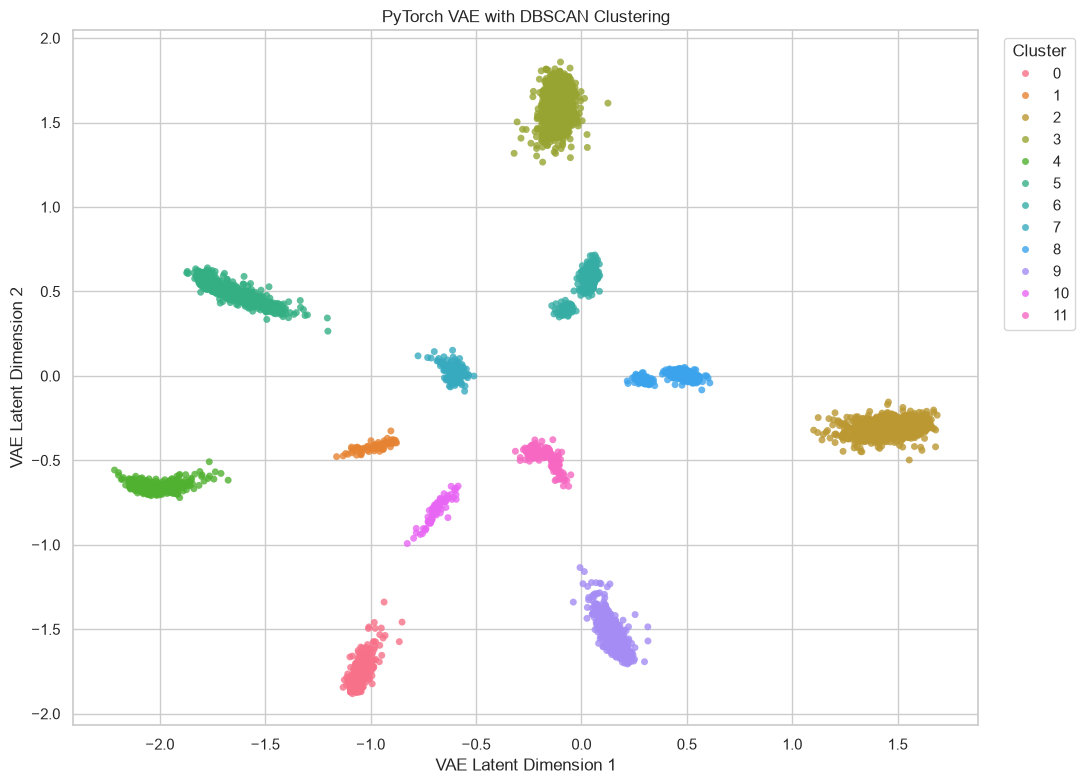

In [24]:
# Get the actual cluster numbers
normal_clusters = sorted(
    [
        cluster
        for cluster in vae_results["cluster"].unique()
        if cluster != -1
    ]
)

# Create one color for each cluster
colors = sns.color_palette(
    "husl",
    len(normal_clusters)
)

cluster_palette = dict(
    zip(
        normal_clusters,
        colors
    )
)

# Show DBSCAN outliers in gray
cluster_palette[-1] = "lightgray"


plt.figure(
    figsize=(11, 8)
)

# Plot patients using DBSCAN cluster as color
sns.scatterplot(
    data=vae_results,
    x="vae_1",
    y="vae_2",
    hue="cluster",
    palette=cluster_palette,
    s=25,
    alpha=0.8,
    linewidth=0
)

plt.title(
    "PyTorch VAE with DBSCAN Clustering"
)

plt.xlabel(
    "VAE Latent Dimension 1"
)

plt.ylabel(
    "VAE Latent Dimension 2"
)

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "vae_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a scatter plot of the VAE latent space with patients colored according to their DBSCAN cluster assignments.
- Assigns a different color to each of the $12$ clusters, while any DBSCAN outliers would be displayed in light gray.
- The plot shows how the identified sepsis patient groups are distributed and separated within the two-dimensional VAE space.
- Saves the visualization as `vae_dbscan_clusters.png` for reporting and further interpretation.
- This block provides a clear visual assessment of the cluster structure produced by the VAE-DBSCAN model.

## Internal Cluster Evaluation

### Remove DBSCAN Outliers for Evaluation

In [25]:
# DBSCAN outliers should not be treated as a normal cluster
evaluation_mask = (
    vae_results["cluster"] != -1
)

# Keep only clustered patients
X_evaluation = vae_results.loc[
    evaluation_mask,
    ["vae_1", "vae_2"]
]

# Corresponding cluster labels
labels_evaluation = vae_results.loc[
    evaluation_mask,
    "cluster"
]

print(
    "Patients used for evaluation:",
    len(X_evaluation)
)

print(
    "Clusters evaluated:",
    labels_evaluation.nunique()
)

Patients used for evaluation: 7648
Clusters evaluated: 12


#### Observation :
- Creates a mask to exclude DBSCAN outliers (`cluster = -1`) from the internal clustering evaluation.
- Keeps only the successfully clustered patients and their two VAE latent dimensions for metric calculation.
- Separates the corresponding cluster labels for the retained patients.
- This ensures the clustering metrics evaluate the quality of the actual patient clusters without treating outliers as a separate cluster.

### Calculate Internal Evaluation Metrics

In [26]:
# Higher Silhouette Score is better
silhouette = silhouette_score(
    X_evaluation,
    labels_evaluation
)

# Lower Davies-Bouldin Index is better
dbi = davies_bouldin_score(
    X_evaluation,
    labels_evaluation
)

# Higher Calinski-Harabasz Index is better
chi = calinski_harabasz_score(
    X_evaluation,
    labels_evaluation
)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)

Silhouette Score: 0.8818
Davies-Bouldin Index: 0.2036
Calinski-Harabasz Index: 161589.02


#### Observation :
- Calculates the Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index to evaluate the quality of the $12$ VAE-DBSCAN clusters.
- The Silhouette Score of $0.8818$ indicates very strong separation between patient clusters.
- The Davies-Bouldin Index of $0.2036$ is low, showing that the clusters are compact and well separated.
- The Calinski-Harabasz Index of $161,589.02$ is very high, providing further evidence of strong cluster structure.
- Overall, these results indicate that the VAE-DBSCAN model produced clearly separated and internally well-defined sepsis patient subgroups.

### Compare the Replication

In [27]:
# Published Ju and Dubin VAE + DBSCAN results
evaluation_summary = pd.DataFrame({

    "metric": [
        "Number of clusters",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "our_replication": [
        n_clusters,
        silhouette,
        dbi,
        chi
    ],

    "ju_dubin_paper": [
        12,
        0.89,
        0.19,
        138637.94
    ]
})

evaluation_summary.round(4)

,metric,our_replication,ju_dubin_paper
0,Number of clusters,12.0000,12.00
1,Silhouette Score,0.8818,0.89
2,Davies-Bouldin Index,0.2036,0.19
3,Calinski-Harabasz Index,161589.0156,138637.94


#### Observation :
- Compares the VAE-DBSCAN clustering results from this analysis with the results reported by Ju and Dubin.
- Both analyses identified $12$ patient clusters, showing successful replication of the reported cluster count.
- The Silhouette Score ($0.8818$ vs. $0.89$) and Davies-Bouldin Index ($0.2036$ vs. $0.19$) are very close to the published values.
- The Calinski-Harabasz Index is higher in this replication ($161,589.02$ vs. $138,637.94$), indicating strong separation between the reproduced clusters.
- Overall, the results closely match the published study and support the successful replication of the VAE-DBSCAN clustering approach.

## Clinical Outcome Evaluation

### Load the Required Clinical Data

In [28]:
# Load only the patient variables required for evaluation
patient = pd.read_csv(
    DATA_DIR / "patient.csv",
    usecols=[
        "patientunitstayid",
        "age",
        "unitdischargeoffset",
        "hospitaldischargeoffset",
        "unitdischargestatus",
        "hospitaldischargestatus"
    ]
)

# Load APACHE severity scores
apache = pd.read_csv(
    DATA_DIR / "apachePatientResult.csv",
    usecols=[
        "patientunitstayid",
        "apacheversion",
        "apachescore"
    ]
)

print(
    "Patient table:",
    patient.shape
)

print(
    "APACHE table:",
    apache.shape
)

Patient table: (200859, 6)
APACHE table: (297064, 3)


#### Observation :
- Loads the patient-level clinical variables needed to evaluate the identified sepsis clusters, including age, discharge status, and length-of-stay information.
- Loads the APACHE patient results containing the APACHE version and severity score for each ICU stay.
- The patient table contains $200,859$ records and $6$ variables, while the APACHE table contains $297,064$ records and $3$ variables.

### Prepare Age and Length of Stay

In [29]:
# Create a copy before modifying the patient table
outcomes = patient.copy()

# eICU represents patients older than 89 as "> 89"
outcomes["age"] = outcomes["age"].replace(
    "> 89",
    "90"
)

# Convert age into numeric form
outcomes["age"] = pd.to_numeric(
    outcomes["age"],
    errors="coerce"
)

# Convert ICU discharge offset from minutes into days
outcomes["icu_los_days"] = (
    outcomes["unitdischargeoffset"]
    / 1440
)

# Convert hospital discharge offset from minutes into days
outcomes["hospital_los_days"] = (
    outcomes["hospitaldischargeoffset"]
    / 1440
)

#### Observation :
- Creates a copy of the patient data so the original clinical dataset remains unchanged.
- Converts the eICU age category $> 89$ to $90$ and changes age into a numeric format for statistical analysis.
- Converts ICU length of stay from minutes to days using the ICU discharge offset.
- Converts hospital length of stay from minutes to days using the hospital discharge offset.
- This block prepares age, ICU stay duration, and hospital stay duration for comparison across the VAE-DBSCAN patient clusters.

### Prepare Mortality Variables

In [30]:
# ICU mortality
# Alive = 0
# Expired = 1
outcomes["icu_mortality"] = (
    outcomes["unitdischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

# Hospital mortality
outcomes["hospital_mortality"] = (
    outcomes["hospitaldischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

print("ICU mortality:")

print(
    outcomes["icu_mortality"]
    .value_counts(
        dropna=False
    )
)

print()

print("Hospital mortality:")

print(
    outcomes["hospital_mortality"]
    .value_counts(
        dropna=False
    )
)

ICU mortality:
icu_mortality
0.0    189918
1.0     10907
NaN        34
Name: count, dtype: int64

Hospital mortality:
hospital_mortality
0.0    181104
1.0     18004
NaN      1751
Name: count, dtype: int64


#### Observation :
- Converts ICU discharge status into a binary mortality variable, where `Alive = 0` and `Expired = 1`.
- Creates the same binary variable for hospital mortality using hospital discharge status.
- The dataset contains $10,907$ ICU deaths and $18,004$ hospital deaths, with only a small number of missing mortality records.
- These variables prepare the key mortality outcomes needed to compare survival differences across the VAE-DBSCAN patient clusters.

### Prepare APACHE IVa Scores

In [31]:
# Keep only APACHE IVa scores
apache_iva = apache[
    apache["apacheversion"] == "IVa"
][
    [
        "patientunitstayid",
        "apachescore"
    ]
].copy()

# Keep one APACHE score per ICU stay
apache_iva = apache_iva.drop_duplicates(
    subset="patientunitstayid"
)

# Rename the score for clarity
apache_iva = apache_iva.rename(
    columns={
        "apachescore": "apache_iva"
    }
)

print(
    "Patients with APACHE IVa:",
    len(apache_iva)
)

Patients with APACHE IVa: 148532


#### Observation :
- Filters the APACHE dataset to keep only APACHE IVa scores, ensuring a consistent severity measure across patients.
- Keeps the patient ICU stay ID and APACHE score required for cluster-level clinical comparison.
- Removes duplicate records so each ICU stay has one APACHE IVa score.
- Renames the score column to `apache_iva` for clearer interpretation.
- A total of $148,532$ ICU stays have an available APACHE IVa score for subsequent clinical analysis.

### Merge Clinical Outcomes with Cluster Assignments

In [32]:
# Combine cluster assignments with clinical outcomes
clinical_results = (
    vae_results
    .merge(
        outcomes,
        on=ID_COL,
        how="left"
    )
    .merge(
        apache_iva,
        on=ID_COL,
        how="left"
    )
)

print(
    "Patients after clinical merge:",
    len(clinical_results)
)

clinical_results.head()

Patients after clinical merge: 7648


,patientunitstayid,vae_1,vae_2,cluster,age,hospitaldischargeoffset,hospitaldischargestatus,unitdischargeoffset,unitdischargestatus,icu_los_days,hospital_los_days,icu_mortality,hospital_mortality,apache_iva
0,151900,-1.065383,-1.779347,0,66.0,6355,Alive,3460,Alive,2.402778,4.413194,0.0,0.0,68.0
1,210208,-1.118235,-0.459498,1,52.0,8352,Alive,5478,Alive,3.804167,5.800000,0.0,0.0,49.0
2,179269,1.497649,-0.330566,2,82.0,24087,Alive,3655,Alive,2.538194,16.727083,0.0,0.0,117.0
3,172764,1.485935,-0.339782,2,71.0,10974,Alive,2077,Alive,1.442361,7.620833,0.0,0.0,NaN
4,166175,-0.105736,1.635214,3,60.0,10037,Alive,1175,Alive,0.815972,6.970139,0.0,0.0,47.0


#### Observation :
- Merges the VAE-DBSCAN cluster assignments with the prepared patient clinical outcomes using `patientunitstayid`.
- Adds age, ICU and hospital length of stay, ICU mortality, hospital mortality, and APACHE IVa severity scores to each clustered ICU stay.
- Uses left joins, ensuring that all $7,648$ clustered patients are retained even if some clinical variables are missing.
- The final merged dataset contains $7,648$ ICU stays, ready for clinical comparison across the identified sepsis clusters.

### Create the Cluster Outcome Summary

In [33]:
# Remove DBSCAN outliers from cluster interpretation
cluster_clinical = clinical_results[
    clinical_results["cluster"] != -1
].copy()

# Calculate clinical characteristics for each cluster
clinical_summary = (
    cluster_clinical
    .groupby("cluster")
    .agg(
        patients=(ID_COL, "size"),
        mean_age=("age", "mean"),
        mean_apache_iva=("apache_iva", "mean"),
        mean_icu_los=("icu_los_days", "mean"),
        mean_hospital_los=("hospital_los_days", "mean"),
        icu_mortality=("icu_mortality", "mean"),
        hospital_mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

# Calculate percentage of clustered patients
clinical_summary["patient_percentage"] = (
    clinical_summary["patients"]
    / clinical_summary["patients"].sum()
    * 100
)

# Convert mortality rates to percentages
clinical_summary["icu_mortality"] *= 100

clinical_summary["hospital_mortality"] *= 100

# Arrange the columns
clinical_summary = clinical_summary[
    [
        "cluster",
        "patients",
        "patient_percentage",
        "mean_age",
        "mean_apache_iva",
        "mean_icu_los",
        "mean_hospital_los",
        "icu_mortality",
        "hospital_mortality"
    ]
]

clinical_summary.round(2)

,cluster,patients,patient_percentage,mean_age,mean_apache_iva,mean_icu_los,mean_hospital_los,icu_mortality,hospital_mortality
0,0,360,4.71,67.24,75.53,3.95,9.16,14.44,19.83
1,1,75,0.98,58.35,75.02,4.52,10.24,18.67,28.77
2,2,2060,26.94,66.49,73.14,3.68,8.34,13.01,19.26
3,3,2128,27.82,66.33,73.57,3.99,8.71,12.55,18.90
4,4,345,4.51,67.41,76.00,4.18,10.59,15.07,19.53
5,5,637,8.33,66.13,72.71,4.89,10.38,11.93,20.41
6,6,517,6.76,61.63,77.25,4.16,9.73,12.96,21.94
7,7,178,2.33,61.13,74.63,4.52,10.89,15.17,21.35
8,8,515,6.73,60.54,72.80,3.97,9.56,11.65,18.83
9,9,560,7.32,65.94,72.14,4.68,9.75,11.07,17.75


#### Observation :
- Groups patients by their VAE-DBSCAN cluster and summarizes key clinical characteristics for each subgroup.
- Calculates cluster size, patient percentage, mean age, APACHE IVa score, ICU length of stay, hospital length of stay, ICU mortality, and hospital mortality.
- Clusters $2$ and $3$ are the largest groups, together representing more than half of the clustered patients.
- Clinical outcomes vary across clusters; for example, Cluster $1$ has the highest hospital mortality at $28.77\%$, while Cluster $9$ has the lowest at $17.75\%$.
- This block shows that the identified clusters represent clinically different sepsis patient subgroups with varying severity and outcomes.

### Plot Hospital Mortality Across Clusters

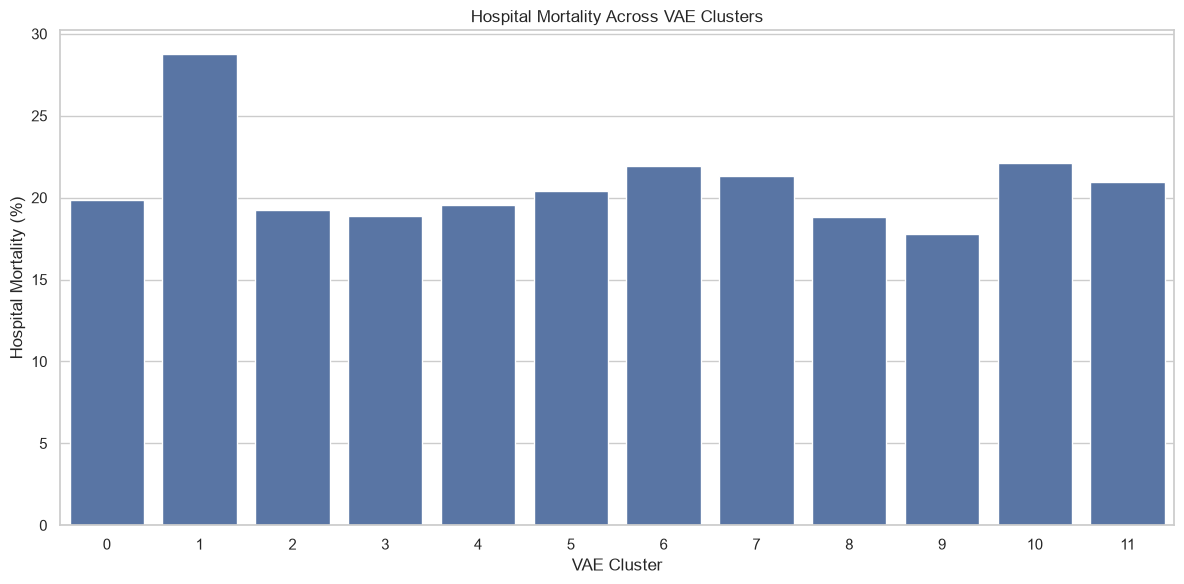

In [34]:
plt.figure(
    figsize=(12, 6)
)

# Compare hospital mortality across VAE clusters
sns.barplot(
    data=clinical_summary,
    x="cluster",
    y="hospital_mortality",
    errorbar=None
)

plt.title(
    "Hospital Mortality Across VAE Clusters"
)

plt.xlabel(
    "VAE Cluster"
)

plt.ylabel(
    "Hospital Mortality (%)"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "vae_hospital_mortality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a bar plot of hospital mortality percentages for all $12$ VAE-DBSCAN patient clusters.
- Cluster $1$ shows the highest hospital mortality at about $28.8\%$, indicating the poorest hospital outcome among the identified subgroups.
- Cluster $9$ has the lowest hospital mortality at about $17.8\%$, while most other clusters range between approximately $19\%$ and $22\%$.
- The variation in mortality across clusters supports that the VAE-DBSCAN model identified clinically distinct sepsis patient subgroups with different outcome risks.
- Saves the figure as `vae_hospital_mortality.png` for reporting and clinical interpretation.

## ICU Survival Evaluation

### Prepare ICU Survival Data

In [35]:
# Keep patients with valid ICU survival information and remove DBSCAN outliers
survival_data = clinical_results[
    (clinical_results["cluster"] != -1)
    & clinical_results["icu_los_days"].notna()
    & clinical_results["icu_mortality"].notna()
    & (clinical_results["icu_los_days"] >= 0)
].copy()

print(
    "Patients:",
    len(survival_data)
)

print(
    "Number of clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data[
            "icu_mortality"
        ].sum()
    )
)

print(
    "Minimum ICU LOS:",
    survival_data[
        "icu_los_days"
    ].min()
)

print(
    "Maximum ICU LOS:",
    survival_data[
        "icu_los_days"
    ].max()
)

Patients: 7648
Number of clusters: 12
ICU deaths: 988
Minimum ICU LOS: 0.0
Maximum ICU LOS: 246.90416666666667


#### Observation :
- Prepares the patient data required for ICU survival analysis across the $12$ VAE-DBSCAN clusters.
- Removes DBSCAN outliers and keeps only patients with valid ICU length of stay and ICU mortality information.
- All $7,648$ patients remain available for survival analysis, with $988$ ICU deaths recorded.
- ICU length of stay ranges from $0$ to approximately $246.9$ days.
- This block creates a clean survival dataset for the subsequent Kaplan-Meier curves and log-rank test.

### Plot Kaplan-Meier Survival Curves

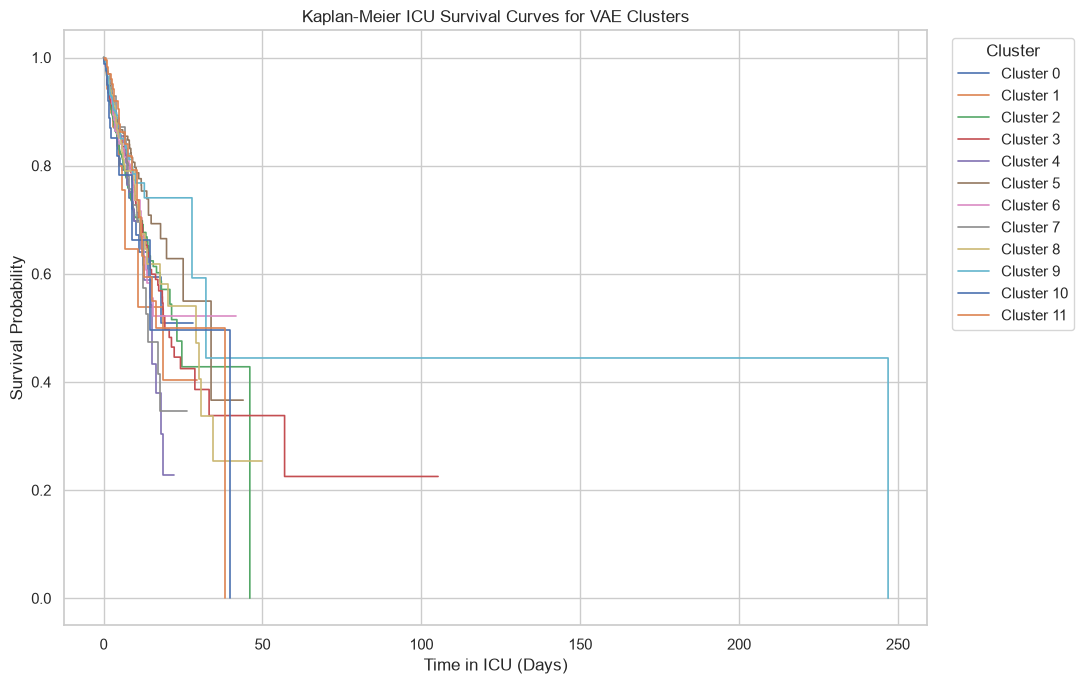

In [36]:
# Create Kaplan-Meier estimator
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Create one survival curve for each cluster
for cluster in sorted(
    survival_data["cluster"].unique()
):

    cluster_data = survival_data[
        survival_data["cluster"] == cluster
    ]

    kmf.fit(
        durations=cluster_data[
            "icu_los_days"
        ],
        event_observed=cluster_data[
            "icu_mortality"
        ],
        label=f"Cluster {cluster}"
    )

    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        linewidth=1.2
    )

ax.set_title(
    "Kaplan-Meier ICU Survival Curves for VAE Clusters"
)

ax.set_xlabel(
    "Time in ICU (Days)"
)

ax.set_ylabel(
    "Survival Probability"
)

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "vae_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Generates Kaplan-Meier survival curves for each of the $12$ VAE-DBSCAN patient clusters.
- Uses ICU length of stay as the survival time and ICU mortality as the observed event.
- The curves allow visual comparison of survival probability over time across the identified sepsis subgroups.
- Differences between the curves indicate possible variation in ICU survival patterns among clusters.
- Saves the survival plot as `vae_kaplan_meier.png` for clinical interpretation and reporting.

### Perform the Global Log-Rank Test

In [37]:
# Test whether ICU survival differs across VAE clusters
logrank_result = multivariate_logrank_test(
    survival_data["icu_los_days"],
    survival_data["cluster"],
    survival_data["icu_mortality"]
)

print(
    "Patients:",
    len(survival_data)
)

print(
    "Clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data[
            "icu_mortality"
        ].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

Patients: 7648
Clusters: 12
ICU deaths: 988
Log-rank statistic: 16.4936
Log-rank p-value: 0.12377418118999625


#### Observation :
- Applies a multivariate log-rank test to compare ICU survival across all $12$ VAE-DBSCAN clusters.
- The test includes $7,648$ patients and $988$ ICU deaths.
- The log-rank test statistic is $16.4936$, with a p-value of $0.1238$.
- Since the p-value is greater than $0.05$, there is no statistically significant difference in ICU survival across the $12$ clusters.
- This indicates that although the clusters differ in several clinical characteristics, their overall ICU survival patterns are not significantly different.

## Clinical Interpretation

### Add Cluster Labels to the Clustering Features

In [38]:
# Copy the original scaled clustering features
cluster_features = scaled_df[
    [ID_COL] + feature_cols
].copy()

# Add VAE DBSCAN cluster labels
cluster_features["cluster"] = (
    vae_results["cluster"].values
)

# Remove DBSCAN outliers
cluster_features = cluster_features[
    cluster_features["cluster"] != -1
].copy()

print(
    "Patients used for interpretation:",
    len(cluster_features)
)

print(
    "Clusters:",
    cluster_features["cluster"].nunique()
)

Patients used for interpretation: 7648
Clusters: 12


#### Observation :
- Copies the original scaled clinical clustering features while keeping each patient’s ICU stay ID.
- Adds the corresponding VAE-DBSCAN cluster label to every patient record.
- Removes any DBSCAN outliers labeled `-1` before clinical interpretation.
- All $7,648$ patients remain available because no outliers were identified.
- The final interpretation dataset contains $12$ patient clusters, ready for comparing their clinical feature patterns.

### Standardize Features for Interpretation

The clustering variables are already Min-Max scaled.

For clinical interpretation only, the variables are standardized so that features with different distributions can be compared on a common scale.

A standardized value:

- Near 0 means close to the overall patient average.
- Above 0 means higher than the overall patient average.
- Below 0 means lower than the overall patient average.

This step is used only for interpreting the clusters. It does not change the VAE or DBSCAN clustering results.

In [39]:
# Calculate the overall feature means
feature_mean = X.mean()

# Calculate the overall feature standard deviations
feature_std = X.std()

# Avoid division by zero for constant features
feature_std = feature_std.replace(
    0,
    np.nan
)

# Standardize each feature
X_standardized = (
    X - feature_mean
) / feature_std

# Add VAE cluster labels
X_standardized["cluster"] = (
    vae_results["cluster"].values
)

# Remove DBSCAN outliers
X_standardized = X_standardized[
    X_standardized["cluster"] != -1
]

X_standardized.head()

,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,cluster
0,0.043316,1.014687,-0.232191,0.123306,-0.744668,-1.132370,-0.684715,-0.140295,0.387933,-0.312693,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,0
1,-0.826669,-0.985397,-0.411240,-0.409269,-0.914413,0.510064,-0.966577,-0.353228,0.387933,-1.011505,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,1
2,1.037584,1.014687,-0.962713,-0.349726,0.613290,-0.099983,-0.812008,1.563175,-0.154015,0.805407,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2
3,0.354024,1.014687,-0.053141,0.080303,-0.914413,2.293277,0.351810,2.201976,-1.057262,-0.452455,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2
4,-0.329535,-0.985397,1.221691,0.821277,-1.084158,0.979330,-0.339207,0.924374,-0.334664,-1.291030,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,3


#### Observation :
- Standardizes all $80$ clinical features so they can be compared on the same scale across patient clusters.
- A standardized value near $0$ represents the overall patient average, while positive and negative values represent higher and lower values than average, respectively.
- Adds the VAE-DBSCAN cluster label to each standardized patient record and removes any DBSCAN outliers.
- This standardization is used only for clinical interpretation and does not change the original VAE or DBSCAN clustering results.

### Calculate Mean Cluster Feature Profiles

In [40]:
# Calculate the average standardized value of every feature within each VAE cluster
cluster_profiles = (
    X_standardized
    .groupby("cluster")
    .mean()
)

print(
    "Cluster profile shape:",
    cluster_profiles.shape
)

cluster_profiles.head()

Cluster profile shape: (12, 80)


,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.120475,1.014687,-0.474723,-0.107700,-0.017713,-0.148344,0.091100,-0.049798,-0.164453,0.077089,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
1,-0.432276,-0.985397,0.473121,0.113629,0.250036,-0.198842,0.029590,0.277055,-0.076938,-0.029441,...,0.051557,0.109538,1.189117,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
2,0.073934,1.014687,-0.508409,-0.193337,-0.106803,-0.094744,0.023678,0.054240,-0.020036,-0.009015,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
3,0.063932,-0.985397,0.555472,0.224321,0.074749,0.183363,-0.008044,-0.045455,0.098232,-0.102721,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
4,0.131215,-0.985397,0.551591,0.293763,0.155102,0.153557,0.037018,-0.166834,-0.018921,-0.056664,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428


#### Observation :
- Groups the standardized patient data by VAE-DBSCAN cluster.
- Calculates the average standardized value of each clinical feature within every cluster.
- Produces a cluster profile matrix containing $12$ clusters and $80$ clinical features.
- These mean profiles show which clinical variables are higher or lower than the overall patient average within each sepsis subgroup.
- This block prepares the data needed to identify the clinical features that most clearly distinguish the $12$ patient clusters.

### Identify the Most Distinguishing Features

In [41]:
# Calculate how much each feature varies across clusters
feature_variation = (
    cluster_profiles
    .std(axis=0)
    .sort_values(
        ascending=False
    )
)

# Keep the 15 features that differ most across clusters
top_profile_features = (
    feature_variation
    .head(15)
    .index
    .tolist()
)

print(
    "Top 15 distinguishing features:"
)

for feature in top_profile_features:
    print(feature)

Top 15 distinguishing features:
unittype_MICU
ethnicity_Caucasian
unittype_Med-Surg ICU
gender
ethnicity_African American
unittype_Cardiac ICU
unittype_CCU-CTICU
ethnicity_Other/Unknown
admissionheight
ethnicity_Hispanic
unittype_SICU
ethnicity_Asian
unittype_Neuro ICU
unittype_CTICU
ethnicity_Native American


#### Observation :
- Calculates how much each of the $80$ clinical features varies across the $12$ VAE-DBSCAN clusters.
- Ranks the features by their between-cluster variation and selects the top $15$ most distinguishing variables.
- The strongest differences are mainly related to ICU unit type, ethnicity, gender, and admission height.
- MICU admission, Caucasian ethnicity, Med-Surg ICU admission, and gender show the greatest variation across clusters.
- These features are selected for the next step to provide a clearer clinical interpretation of how the patient subgroups differ.

### Plot the Clinical Feature Heatmap

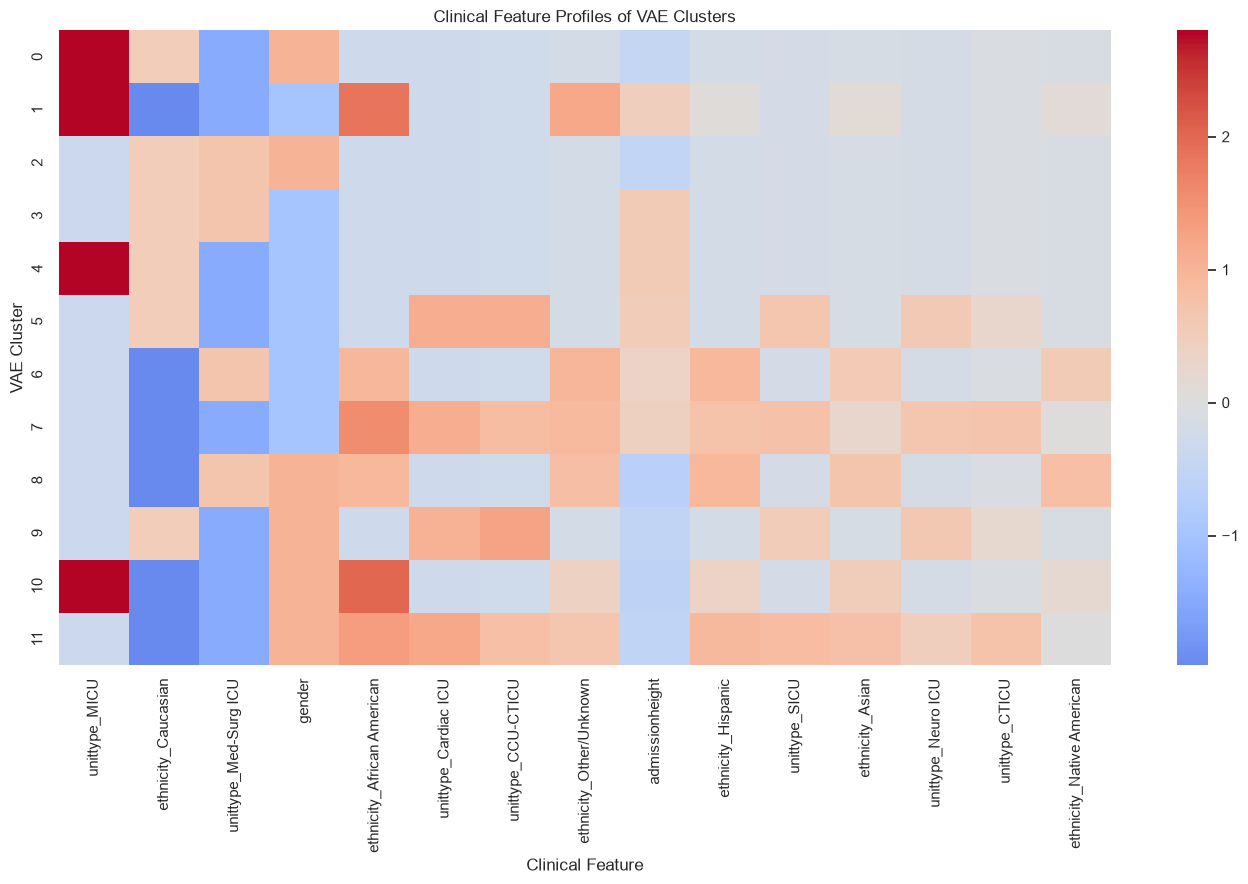

In [42]:
plt.figure(
    figsize=(14, 9)
)

# Display whether important clinical features
# are relatively high or low within each cluster
sns.heatmap(
    cluster_profiles[
        top_profile_features
    ],
    cmap="coolwarm",
    center=0
)

plt.title(
    "Clinical Feature Profiles of VAE Clusters"
)

plt.xlabel(
    "Clinical Feature"
)

plt.ylabel(
    "VAE Cluster"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "vae_cluster_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a heatmap of the top $15$ clinical features that differ most across the $12$ VAE-DBSCAN clusters.
- Red values indicate features that are higher than the overall average, while blue values indicate features that are lower than average within each cluster.
- The heatmap shows clear differences in ICU unit type, ethnicity, gender, and admission height, confirming that the clusters have distinct clinical profiles.
- For example, MICU representation is notably higher in Clusters $0$, $1$, $4$, and $10$, while several other clusters show lower MICU representation.
- This visualization helps translate the VAE-DBSCAN clusters into clinically interpretable sepsis patient subgroups.

## Save Essential Results

### Save VAE Cluster Assignments

In [43]:
# Save patient IDs, VAE coordinates, and cluster labels
vae_results.to_csv(
    RESULTS_DIR / "vae_dbscan_clusters.csv",
    index=False
)

print(
    "Saved: vae_dbscan_clusters.csv"
)

Saved: vae_dbscan_clusters.csv


### Save Internal Evaluation Summary

In [44]:
# Save our VAE clustering metrics together with the Ju and Dubin benchmarks
evaluation_summary.to_csv(
    RESULTS_DIR / "vae_evaluation_summary.csv",
    index=False
)

print(
    "Saved: vae_evaluation_summary.csv"
)

Saved: vae_evaluation_summary.csv


### Save Clinical Outcome Summary

In [45]:
# Save the clinical characteristics of every VAE cluster
clinical_summary.to_csv(
    RESULTS_DIR / "vae_clinical_summary.csv",
    index=False
)

print(
    "Saved: vae_clinical_summary.csv"
)

Saved: vae_clinical_summary.csv


## Verify Saved Files

In [46]:
print("Saved result files:")
print()

for file in sorted(
    RESULTS_DIR.glob("*.csv")
):
    print(file.name)

print()

print("Saved plot files:")
print()

for file in sorted(
    PLOTS_DIR.glob("*.png")
):
    print(file.name)

Saved result files:

vae_clinical_summary.csv
vae_dbscan_clusters.csv
vae_evaluation_summary.csv

Saved plot files:

vae_cluster_feature_heatmap.png
vae_dbscan_clusters.png
vae_hospital_mortality.png
vae_kaplan_meier.png
vae_latent_representation.png


## Final Summary

In [47]:
print(
    "PyTorch VAE + DBSCAN Final Summary"
)

print(
    "=" * 50
)


print()
print("Dataset")

print(
    "Patients:",
    len(vae_results)
)

print(
    "Clustering features:",
    len(feature_cols)
)


print()
print("VAE Parameters")

print(
    "Hidden layer 1:",
    VAE_HIDDEN_1
)

print(
    "Hidden layer 2:",
    VAE_HIDDEN_2
)

print(
    "Latent dimensions:",
    VAE_LATENT_DIM
)

print(
    "Learning rate:",
    VAE_LEARNING_RATE
)

print(
    "Beta:",
    VAE_BETA
)

print(
    "Batch size:",
    VAE_BATCH_SIZE
)

print(
    "Epochs:",
    VAE_EPOCHS
)


print()
print("DBSCAN Parameters")

print(
    "Epsilon:",
    DBSCAN_EPS
)

print(
    "Min samples:",
    DBSCAN_MIN_SAMPLES
)


print()
print("Clustering Result")

print(
    "Clusters:",
    n_clusters
)

print(
    "Outliers:",
    n_outliers
)

print(
    "Outlier percentage:",
    round(
        outlier_percentage,
        2
    ),
    "%"
)


print()
print("Internal Evaluation")

print(
    "Silhouette Score:",
    round(
        silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        dbi,
        4
    )
)

print(
    "Calinski-Harabasz Index:",
    round(
        chi,
        2
    )
)


print()
print("Survival Evaluation")

print(
    "Patients:",
    len(survival_data)
)

print(
    "ICU deaths:",
    int(
        survival_data[
            "icu_mortality"
        ].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

PyTorch VAE + DBSCAN Final Summary

Dataset
Patients: 7648
Clustering features: 80

VAE Parameters
Hidden layer 1: 256
Hidden layer 2: 128
Latent dimensions: 2
Learning rate: 0.0001
Beta: 0.1
Batch size: 128
Epochs: 50

DBSCAN Parameters
Epsilon: 0.2
Min samples: 50

Clustering Result
Clusters: 12
Outliers: 0
Outlier percentage: 0.0 %

Internal Evaluation
Silhouette Score: 0.8818
Davies-Bouldin Index: 0.2036
Calinski-Harabasz Index: 161589.02

Survival Evaluation
Patients: 7648
ICU deaths: 988
Log-rank statistic: 16.4936
Log-rank p-value: 0.12377418118999625


## Final Notebook Workflow
```
feature_data_scaled.csv
          │
          ▼
   PyTorch VAE
          │
          │  64 neurons
          │       ↓
          │  32 neurons
          │       ↓
          ▼
   2-D Latent Space
          │
          │  Use latent mean
          ▼
       DBSCAN
          │
          │  eps = 0.20
          │  min_samples = 80
          ▼
   Cluster Assignments
          │
    ┌─────┴─────┐
    │           │
    ▼           ▼
Internal     Clinical
Evaluation   Outcomes
    │           │
    ▼           ▼
Ju & Dubin   Mortality
Comparison      │
                ▼
          Survival Analysis
                │
                ▼
        Clinical Profiles
                │
                ▼
          Feature Heatmap
                │
                ▼
      Save Essential Results
```